<a href="https://colab.research.google.com/github/rojaspetit/analysis_connectatel/blob/main/analysis_connectatel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis del comportamiento de clientes de ConnectaTel

## Contexto del proyecto

ConnectaTel es una empresa de telecomunicaciones con operaciones en México y Colombia. El análisis busca comprender los patrones de uso de sus clientes a partir de la actividad registrada en llamadas y mensajes.

El proyecto se centra en construir un perfil analítico a nivel de cliente, evaluar la calidad de los datos, identificar comportamientos atípicos y segmentar a los usuarios según sus características demográficas y nivel de uso.

## Objetivo

Analizar el comportamiento de los clientes de ConnectaTel para identificar patrones de consumo, detectar usuarios con actividad atípica y comprender cómo varía el uso de los servicios entre segmentos de edad y planes contratados.

El análisis busca responder las siguientes preguntas:

- ¿Cómo utilizan los clientes los servicios de llamadas y mensajería?
- ¿Qué usuarios presentan patrones de consumo atípicos?
- ¿Cómo varía el nivel de uso entre diferentes segmentos de edad?
- ¿Existen diferencias en el comportamiento de uso según el plan contratado?
- ¿Qué hallazgos pueden apoyar decisiones comerciales y futuras mejoras en la oferta de servicios?

## Datos utilizados

El análisis parte de tres datasets:

- `plans.csv`: características de los planes disponibles.
- `users_latam.csv`: información demográfica y contractual de los clientes.
- `usage.csv`: registros de actividad correspondientes a llamadas y mensajes.

El periodo de actividad observado en `usage.csv` comprende registros de enero a junio de 2024.

---
## 1. Carga y exploración inicial


### 1.1. Carga de librerías, repositorio y datasets

In [55]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [56]:
# Cargar repositorio de GitHub
%cd /content
!rm -rf /content/analysis_connectatel
!git clone https://github.com/rojaspetit/analysis_connectatel.git
%cd /content/analysis_connectatel

/content
Cloning into 'analysis_connectatel'...
remote: Enumerating objects: 66, done.
remote: Counting objects: 100% (66/66), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 66 (delta 22), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (66/66), 1.42 MiB | 3.21 MiB/s, done.
Resolving deltas: 100% (22/22), done.
/content/analysis_connectatel


In [57]:
# Cargar archivos
plans = pd.read_csv('datasets/plans.csv')
users = pd.read_csv('datasets/users_latam.csv')
usage = pd.read_csv('datasets/usage.csv')

In [58]:
# Vista preliminar de los datasets
print("PLANS")
display(plans.head())

print("USERS")
display(users.head())

print("USAGE")
display(usage.head())

PLANS


,fplan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


USERS


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


USAGE


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


### 1.2 Exploración de la estructura de los datasets

Se revisan las dimensiones, tipos de datos y estructura inicial de los tres datasets para identificar posibles problemas de calidad antes del procesamiento.

In [59]:
# Revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [60]:
# Inspección de plans
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fplan_name         2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 260.0+ bytes


In [61]:
# Inspección de users
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [62]:
# Inspección de usage
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 2. Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

Se evalúa la cantidad y proporción de valores faltantes en los datasets de usuarios y uso para identificar variables que requieren revisión o tratamiento.

In [63]:
# Cantidad de nulos para users
print("Cantidad de nulos en users:\n", users.isna().sum().sort_values(ascending=False))
print("\nProporción de nulos en users:\n", users.isna().mean().sort_values(ascending=False))

Cantidad de nulos en users:
 churn_date    3534
city           469
user_id          0
first_name       0
age              0
last_name        0
reg_date         0
plan             0
dtype: int64

Proporción de nulos en users:
 churn_date    0.88350
city          0.11725
user_id       0.00000
first_name    0.00000
age           0.00000
last_name     0.00000
reg_date      0.00000
plan          0.00000
dtype: float64


In [64]:
# Cantidad de nulos para usage
print("Cantidad de nulos en usage:\n", usage.isna().sum().sort_values(ascending=False))
print("\nProporción de nulos en usage:\n", usage.isna().mean().sort_values(ascending=False))

Cantidad de nulos en usage:
 duration    22076
length      17896
date           50
id              0
user_id         0
type            0
dtype: int64

Proporción de nulos en usage:
 duration    0.55190
length      0.44740
date        0.00125
id          0.00000
user_id     0.00000
type        0.00000
dtype: float64


### 2.2 Detección de valores inválidos y sentinels

Se revisan las variables numéricas y categóricas para identificar valores fuera de rango, sentinels y categorías inconsistentes.

El dataset `plans` solamente tiene 2 renglones, por ello no se le realiza exploración adicional.

In [65]:
# Explorar columnas numéricas de users

print("Exploración de user_id:\n", users["user_id"].describe())
print("\nExploración de age:\n", users["age"].describe())
print("\nSentinels en age:", users["age"].isin([-999]).sum())

Exploración de user_id:
 count     4000.000000
mean     11999.500000
std       1154.844867
min      10000.000000
25%      10999.750000
50%      11999.500000
75%      12999.250000
max      13999.000000
Name: user_id, dtype: float64

Exploración de age:
 count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

Sentinels en age: 55


- La columna `user_id` es una columna de identificadores, sin valores duplicados o nulos. La data no indica anomalías.
- La columna `age` tiene un sentinel / valor inválido como -999, presente en el 1.38% de los casos.

In [66]:
# Explorar columnas numéricas de usage

print("Exploración de id:\n", usage["id"].describe())
print("\nExploración de user_id:\n", usage["user_id"].describe())

Exploración de id:
 count    40000.00000
mean     20000.50000
std      11547.14972
min          1.00000
25%      10000.75000
50%      20000.50000
75%      30000.25000
max      40000.00000
Name: id, dtype: float64

Exploración de user_id:
 count    40000.000000
mean     12002.405975
std       1157.279564
min      10000.000000
25%      10996.000000
50%      12013.000000
75%      13005.000000
max      13999.000000
Name: user_id, dtype: float64


- Las columnas `id` y `user_id`son identificadores de la operación (id) y el usuario que la realiza (user_id)
- Las columna `id` es una columna de identificadores, sin valores duplicados o nulos. La data no indica anomalías.

In [67]:
# Explorar columnas categóricas de users
columnas_user = ["city", "plan"]

print("Exploración de city y plan:\n", users[columnas_user].describe())
print("\nConteo de valores por city y plan:\n", users[columnas_user].value_counts())
print("\nProporción de city con '?':", (users["city"] == "?").mean())

Exploración de city y plan:
           city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595

Conteo de valores por city y plan:
 city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
Name: count, dtype: int64

Proporción de city con '?': 0.024


- La columna `city` cuenta con 7 valores únicos, entre los cuales está el sentinel "?", presente en el 2.4% de los casos.
- La columna `plan` contiene dos categorías. El plan Básico es el predominante, con aproximadamente el 64.9% de los usuarios.

In [68]:
# Explorar columna categórica de usage

print("Exploración de type:\n", usage['type'].describe())
print("\nConteo de valores de type:\n", usage['type'].value_counts())

Exploración de type:
 count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

Conteo de valores de type:
 type
text    22092
call    17908
Name: count, dtype: int64


- La columna `type` tiene 2 categorías. Los mensajes de texto representan el tipo de evento más frecuente en los registros de uso disponibles.

### 2.3 Revisión de fechas

Se convierten las variables temporales al formato `datetime` y se revisan los años presentes para identificar fechas fuera del periodo esperado.

In [69]:
# Convertir a fecha la columna `reg_date` de users
users["reg_date"] = pd.to_datetime(users["reg_date"], errors="coerce")

In [70]:
# Revisar los años presentes en `reg_date` de users
users["reg_date"].dt.year.value_counts().sort_index()

,count
reg_date,
2022,1314
2023,1316
2024,1330
2026,40


En `reg_date`, se identificaron 40 fechas de registro correspondientes a 2026, fuera del periodo temporal esperado del dataset. Estos valores se normalizaron como NaT. Las fechas faltantes en usage se conservaron, ya que el análisis se centra en métricas agregadas de uso y los registros mantienen información válida sobre llamadas y mensajes.

In [71]:
# Convertir a fecha la columna `date` de usage
usage["date"] = pd.to_datetime(usage["date"], errors="coerce")

In [72]:
# Revisar los años presentes en `date` de usage
usage["date"].dt.year.value_counts().sort_index()

,count
date,
2024.0,39950


En `date`, todos los registros no-nulos son del año 2024. Basaremos el análisis en estas fechas.

---

## 3. Limpieza de datos

### 3.1 Tratamiento de valores inválidos

A partir de los problemas identificados durante la exploración, se normalizan los valores sentinels, categorías inconsistentes y fechas fuera del periodo esperado.

In [73]:
# Normalizar el sentinel -999 e imputar los valores faltantes con la mediana
users["age"] = users["age"].replace(-999, np.nan)
age_mediana = users["age"].median()
users["age"] = users["age"].fillna(age_mediana)

# Verificar cambios
users["age"].describe()

,age
count,4000.000000
mean,48.136000
std,17.689919
min,18.000000
25%,33.000000
50%,48.000000
75%,63.000000
max,79.000000


In [74]:
# Normalizar el sentinel "?" como valor faltante
users["city"] = users["city"].replace("?", pd.NA)

# Verificar cambios
users["city"].value_counts(dropna=True)

,count
city,
Bogotá,808
CDMX,730
Medellín,616
GDL,450
Cali,424
MTY,407


In [75]:
# Normalizar fechas de registro fuera del periodo esperado a NaT
users.loc[users["reg_date"].dt.year == 2026, "reg_date"] = pd.NaT

# Verificar cambios
users["reg_date"].dt.year.value_counts(dropna=True).sort_index()

,count
reg_date,
2022.0,1314
2023.0,1316
2024.0,1330


### 3.2 Tratamiento de valores no aplicables según el tipo de evento

Se analiza la relación entre `type`, `duration` y `length` para determinar si los valores faltantes responden a la estructura de los eventos registrados y detectar posibles inconsistencias.

In [76]:
# Revisar la ausencia de duration según el tipo de evento
usage["duration"].isna().groupby(usage["type"]).mean().sort_values(ascending=False)

,duration
type,
text,0.999276
call,0.000000


In [77]:
# Revisar la ausencia de length según el tipo de evento
usage["length"].isna().groupby(usage["type"]).mean().sort_values(ascending=False)

,length
type,
call,0.99933
text,0.00000


In [78]:
# Verificar valores informados en campos no aplicables según el tipo de evento
usage.groupby("type")[["duration", "length"]].count()

,duration,length
type,,
call,17908,12
text,16,22092


In [79]:
# Identificar registros inconsistentes según el tipo de evento
calls_with_length = usage[
    (usage["type"] == "call") &
    (usage["length"].notna())
]

texts_with_duration = usage[
    (usage["type"] == "text") &
    (usage["duration"].notna())
]

print("Llamadas con longitud registrada:")
display(calls_with_length)

print("Mensajes con duración registrada:")
display(texts_with_duration)

Llamadas con longitud registrada:


,id,user_id,type,date,duration,length
2070,2071,13139,call,2024-01-10 08:48:27.432685817,1.68,1490.0
5272,5273,11750,call,2024-01-24 20:33:12.649816245,3.78,1490.0
10614,10615,13855,call,2024-02-18 00:42:33.183829595,0.53,1490.0
12692,12693,12263,call,2024-02-27 10:23:08.374709367,1.80,1490.0
16910,16911,12099,call,2024-03-17 12:28:18.882472061,3.29,1490.0
20727,20728,10599,call,2024-04-03 19:00:30.510762768,0.40,1490.0
20778,20779,11401,call,2024-04-04 00:32:49.969249231,1.01,1490.0
25444,25445,10781,call,2024-04-25 03:17:14.935873396,3.57,1490.0
26057,26058,11018,call,2024-04-27 21:51:39.407485186,0.63,1490.0
26506,26507,12400,call,2024-04-29 22:37:24.836120902,1.12,1490.0


Mensajes con duración registrada:


,id,user_id,type,date,duration,length
1414,1415,10399,text,2024-01-07 09:33:51.260781519,120.0,65.0
1824,1825,12936,text,2024-01-09 06:05:28.868221705,120.0,40.0
1932,1933,10189,text,2024-01-09 17:49:13.603840096,120.0,69.0
2972,2973,10085,text,2024-01-14 10:46:02.169054226,120.0,68.0
11456,11457,13325,text,2024-02-21 20:09:09.733743343,120.0,23.0
16702,16703,10484,text,2024-03-16 13:52:57.169429235,120.0,48.0
22814,22815,12711,text,2024-04-13 05:39:44.429610740,120.0,70.0
23052,23053,13850,text,2024-04-14 07:30:35.235880896,120.0,24.0
23451,23452,13265,text,2024-04-16 02:50:32.175804394,120.0,53.0
26561,26562,13920,text,2024-04-30 04:35:48.173704342,120.0,89.0


Los valores faltantes en duration y length están directamente relacionados con el tipo de evento registrado. La duración no aplica a los mensajes de texto, mientras que la longitud del mensaje no aplica a las llamadas.

Además del patrón de valores faltantes estructurales, se identificaron registros con información en campos no aplicables: llamadas con longitud de mensaje y mensajes con duración registrada. Estas inconsistencias presentan valores constantes (1490 y 120, respectivamente), por lo que se normalizarán como valores no aplicables.

In [80]:
# Normalizar como valores no aplicables las llamadas con length y los mensajes con duration
usage.loc[usage["type"] == "call", "length"] = np.nan
usage.loc[usage["type"] == "text", "duration"] = np.nan

In [81]:
# Validar valores no aplicables en duration
usage["duration"].isna().groupby(usage["type"]).mean()

,duration
type,
call,0.0
text,1.0


In [82]:
# Validar valores no aplicables en length
usage["length"].isna().groupby(usage["type"]).mean()

,length
type,
call,1.0
text,0.0


---

## 4. Construcción del perfil analítico por usuario

### 4.1 Agregación del comportamiento de uso

Los registros de actividad se agrupan por `user_id` para construir métricas de uso a nivel de cliente: cantidad de mensajes, cantidad de llamadas y minutos totales de llamada.

Posteriormente, estas métricas se integran con la información de usuarios para construir el dataset analítico `user_profile`.

In [83]:
# Crear columnas auxiliares según el tipo de evento
usage["is_text"] = (usage["type"] == "text").astype(int)
usage["is_call"] = (usage["type"] == "call").astype(int)

# Agrupar métricas de uso por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# Renombrar las métricas agregadas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamados"
})

# Observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamados
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [84]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(
    users,
    usage_agg,
    on="user_id",
    how="left"
)

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamados
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


In [85]:
# Validar la estructura del dataset analítico
print("Dimensiones de user_profile:", user_profile.shape)
print("Usuarios únicos:", user_profile["user_id"].nunique())
print("Duplicados por user_id:", user_profile["user_id"].duplicated().sum())

user_profile.info()

Dimensiones de user_profile: (4000, 11)
Usuarios únicos: 4000
Duplicados por user_id: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   user_id                4000 non-null   int64         
 1   first_name             4000 non-null   object        
 2   last_name              4000 non-null   object        
 3   age                    4000 non-null   float64       
 4   city                   3435 non-null   object        
 5   reg_date               3960 non-null   datetime64[ns]
 6   plan                   4000 non-null   object        
 7   churn_date             466 non-null    object        
 8   cant_mensajes          3999 non-null   float64       
 9   cant_llamadas          3999 non-null   float64       
 10  cant_minutos_llamados  3999 non-null   float64       
dtypes: datetime64[ns](1), float64(4),

In [86]:
# Revisar valores faltantes en las métricas agregadas de uso
user_profile[
    ["cant_mensajes", "cant_llamadas", "cant_minutos_llamados"]
].isna().sum()

,0
cant_mensajes,1
cant_llamadas,1
cant_minutos_llamados,1


La integración conserva los 4,000 usuarios sin generar duplicados por `user_id`. Se identificó un único usuario sin métricas de uso asociadas, cuyos valores faltantes se conservarán para distinguir la ausencia de registros observados de una actividad confirmada igual a cero.

### 4.2 Resumen estadístico del perfil de usuarios

Se revisan las principales variables numéricas del perfil analítico y la distribución proporcional de los usuarios según el plan contratado.

In [87]:
# Resumen estadístico de las columnas numéricas
columnas_num = [
    "age",
    "cant_mensajes",
    "cant_llamadas",
    "cant_minutos_llamados"
]
user_profile[columnas_num].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamados
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,22.836934
std,17.689919,2.358416,2.144238,16.590213
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.095000
50%,48.000000,5.000000,4.000000,19.740000
75%,63.000000,7.000000,6.000000,31.185000
max,79.000000,17.000000,15.000000,155.690000


In [88]:
# Distribución proporcional de usuarios por tipo de plan
user_profile["plan"].value_counts(normalize=True)

,proportion
plan,
Basico,0.64875
Premium,0.35125


---

## 5. Análisis de distribuciones y valores atípicos

### 5.1 Distribución de las variables principales

Se analiza la distribución de la edad y las principales métricas de uso para identificar patrones de comportamiento y observar posibles diferencias según el plan contratado.

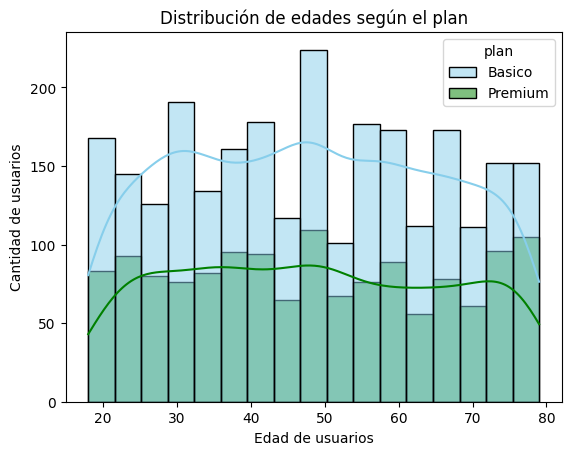

In [89]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x="age", hue="plan", palette=["skyblue","green"], kde=True)
plt.xlabel("Edad de usuarios")
plt.ylabel("Cantidad de usuarios")
plt.title("Distribución de edades según el plan")
plt.show()

- La distribución de edades es relativamente uniforme y no se observan diferencias claras entre los usuarios de los planes Básico y Premium.

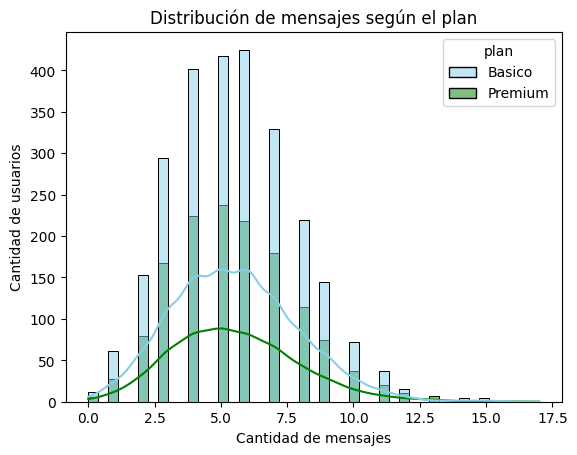

In [90]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x="cant_mensajes", hue="plan", palette=["skyblue","green"], kde=True)
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Cantidad de usuarios")
plt.title("Distribución de mensajes según el plan")
plt.show()

La cantidad de mensajes presenta una distribución sesgada a la derecha. La mayor concentración de usuarios registra entre 4 y 7 mensajes, con un patrón similar en ambos planes.

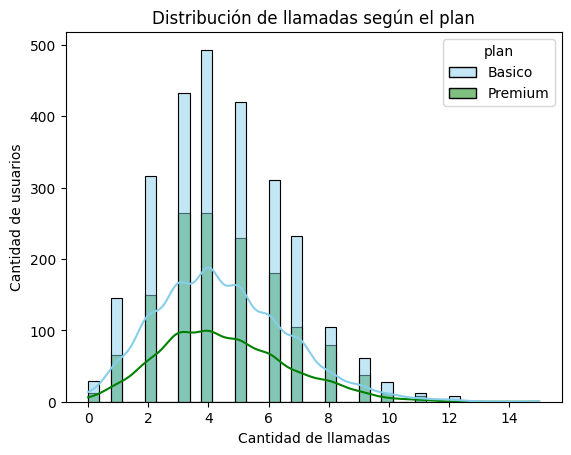

In [91]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x="cant_llamadas", hue="plan", palette=["skyblue","green"], kde=True)
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Cantidad de usuarios")
plt.title("Distribución de llamadas según el plan")
plt.show()

La cantidad de llamadas presenta una distribución sesgada a la derecha. La mayor concentración de usuarios registra entre 3 y 6 llamadas, con un comportamiento similar entre ambos planes.

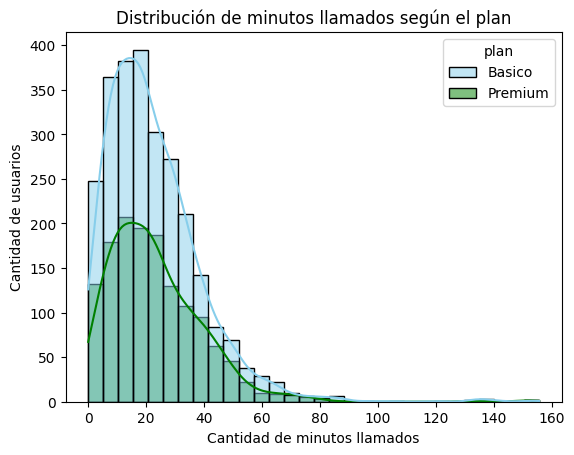

In [92]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x="cant_minutos_llamados", bins=30, hue="plan", palette=["skyblue","green"], kde=True)
plt.xlabel("Cantidad de minutos llamados")
plt.ylabel("Cantidad de usuarios")
plt.title("Distribución de minutos llamados según el plan")
plt.show()

Los minutos totales de llamada presentan una distribución sesgada a la derecha. La mayoría de los usuarios se concentra entre 10 y 30 minutos, aunque se observan valores extremos elevados.

### 5.2 Identificación de valores atípicos

Se utilizan boxplots y el método del rango intercuartílico (IQR) para identificar observaciones extremas en las principales métricas de uso y evaluar si requieren tratamiento.

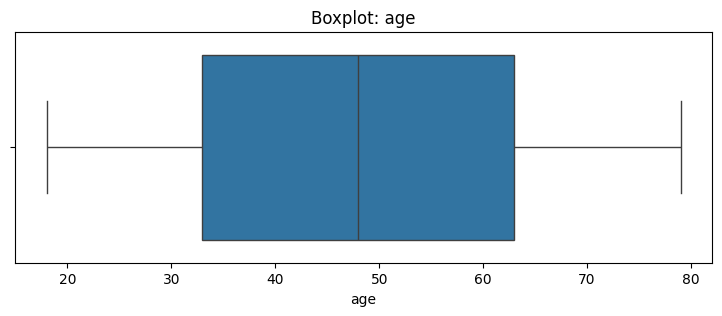

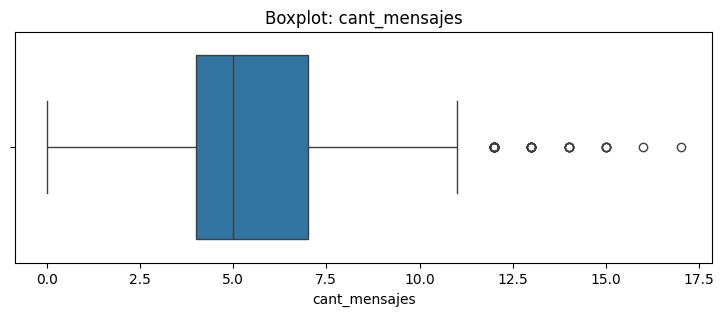

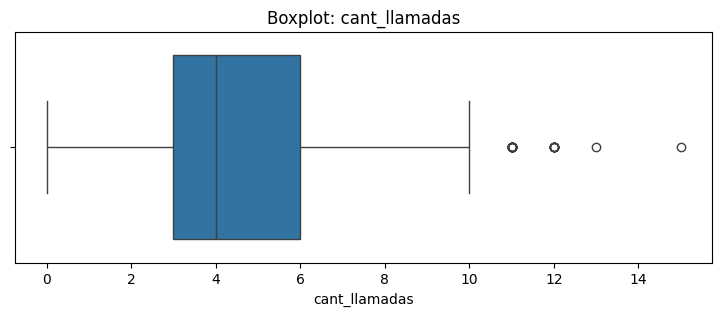

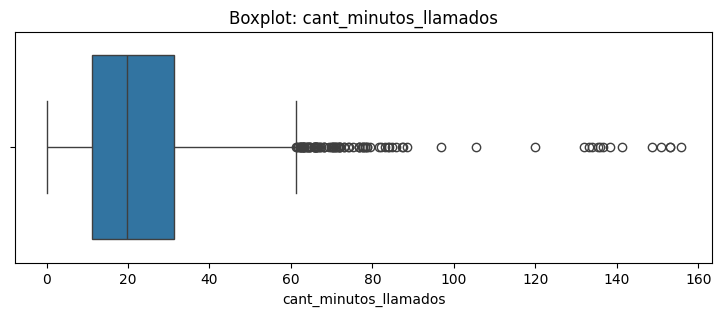

In [93]:
# Visualizar la distribución y posibles valores atípicos
columnas_numericas = [
    "age",
    "cant_mensajes",
    "cant_llamadas",
    "cant_minutos_llamados"
]

for col in columnas_numericas:
    plt.figure(figsize=(9,3))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

La variable `age` no presenta valores atípicos según la inspección visual. En cambio, `cant_mensajes`, `cant_llamadas` y `cant_minutos_llamados` presentan observaciones extremas en el límite superior de sus distribuciones.

In [94]:
# Calcular límites con el método IQR
columnas_limites = [
    "cant_mensajes",
    "cant_llamadas",
    "cant_minutos_llamados"
]

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = user_profile[
        (user_profile[col] < lower) |
        (user_profile[col] > upper)
    ]

    print(f"\nVariable: {col}")
    print(f"Límite inferior: {lower:.2f}")
    print(f"Límite superior: {upper:.2f}")
    print(f"Cantidad de outliers: {len(outliers)}")



Variable: cant_mensajes
Límite inferior: -0.50
Límite superior: 11.50
Cantidad de outliers: 46

Variable: cant_llamadas
Límite inferior: -1.50
Límite superior: 10.50
Cantidad de outliers: 30

Variable: cant_minutos_llamados
Límite inferior: -19.04
Límite superior: 61.32
Cantidad de outliers: 96


Las métricas de mensajes, llamadas y minutos presentan valores atípicos según el método IQR. Sin embargo, los registros identificados mantienen valores coherentes con la estructura de los datos y representan usuarios con niveles de actividad superiores al comportamiento habitual. Por este motivo, los outliers se conservarán para el análisis, ya que pueden reflejar patrones reales de uso relevantes para la identificación de clientes con comportamiento atípico.

---

## 6. Segmentación y comparación de clientes

### 6.1 Segmentación de clientes por nivel de uso

Los clientes se clasifican mediante reglas predefinidas basadas en la cantidad de llamadas y mensajes registrados:

- **Bajo uso:** menos de 5 llamadas y menos de 5 mensajes.
- **Uso medio:** menos de 10 llamadas y menos de 10 mensajes.
- **Alto uso:** usuarios que no cumplen las condiciones anteriores.
- **Sin datos de uso:** usuarios sin registros observados de llamadas y mensajes.

In [95]:
# Crear segmentos de usuarios según su nivel de uso
user_profile["grupo_uso"] = np.where(
    user_profile["cant_llamadas"].isna() &
    user_profile["cant_mensajes"].isna(),
    "Sin datos de uso",
    np.where(
        (user_profile["cant_llamadas"] < 5) &
        (user_profile["cant_mensajes"] < 5),
        "Bajo uso",
        np.where(
            (user_profile["cant_llamadas"] < 10) &
            (user_profile["cant_mensajes"] < 10),
            "Uso medio",
            "Alto uso"
        )
    )
)

In [96]:
# Establecer orden para los segmentos según nivel de uso
orden_segmentos = [
    "Bajo uso",
    "Uso medio",
    "Alto uso",
    "Sin datos de uso"
]

In [97]:
# Validar la distribución de los segmentos de uso
user_profile["grupo_uso"].value_counts(dropna=False).reindex(orden_segmentos)

,count
grupo_uso,
Bajo uso,778
Uso medio,2943
Alto uso,278
Sin datos de uso,1


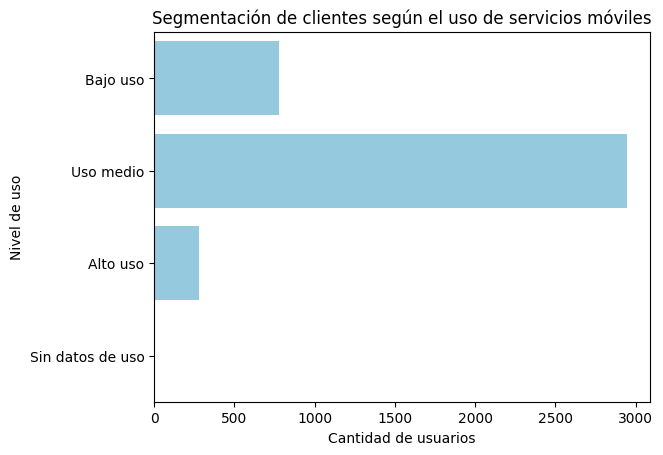

In [98]:
# Visualización de los segmentos por uso
sns.countplot(
    data=user_profile,
    y="grupo_uso",
    order=orden_segmentos,
    color="skyblue"
)

plt.xlabel("Cantidad de usuarios")
plt.ylabel("Nivel de uso")
plt.title("Segmentación de clientes según el uso de servicios móviles")
plt.show()

Los usuarios se segmentaron mediante reglas predefinidas basadas en la cantidad de llamadas y mensajes registrados. Se añadió una categoría independiente para los usuarios sin datos de uso observados, evitando clasificarlos incorrectamente dentro de los segmentos de actividad.

### 6.2 Segmentación de clientes por edad

Los usuarios se agrupan en tres segmentos demográficos para comparar sus patrones de uso:

- **Joven:** menores de 30 años.
- **Adulto:** entre 30 y 59 años.
- **Adulto Mayor:** 60 años o más.

In [99]:
# Crear columna grupo_edad
user_profile["grupo_edad"] = np.where(
    user_profile["age"] < 30, "Joven",
        np.where(user_profile["age"] < 60, "Adulto", "Adulto Mayor")
)

In [100]:
# Establecer orden para los segmentos según edad
orden_edades = [
    "Joven",
    "Adulto",
    "Adulto Mayor"
]

In [101]:
# Validar la distribución de los segmentos de edad
user_profile["grupo_edad"].value_counts().reindex(orden_edades)

,count
grupo_edad,
Joven,760
Adulto,2018
Adulto Mayor,1222


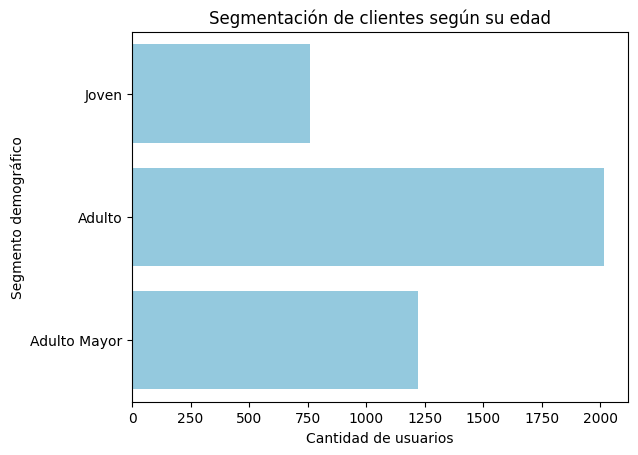

In [102]:
# Visualización de los segmentos por edad
sns.countplot(
    data=user_profile,
    y="grupo_edad",
    order=orden_edades,
    color="skyblue"
)

plt.xlabel("Cantidad de usuarios")
plt.ylabel("Segmento demográfico")
plt.title("Segmentación de clientes según su edad")
plt.show()

### 6.3 Análisis cruzado entre edad y nivel de uso

Se compara la distribución proporcional de los niveles de uso dentro de cada segmento de edad para evaluar si existen diferencias relevantes en el comportamiento de los grupos demográficos.

In [103]:
# Análisis cruzado entre grupo_edad y grupo_uso

tabla_segmentos = (
    pd.crosstab(
        user_profile["grupo_edad"],
        user_profile["grupo_uso"],
        normalize="index"
    )
    .mul(100)
    .reindex(index=["Joven", "Adulto", "Adulto Mayor"])
    .reindex(columns=["Bajo uso", "Uso medio", "Alto uso"])
    .round(2)
)

tabla_segmentos

grupo_uso,Bajo uso,Uso medio,Alto uso
grupo_edad,,,
Joven,20.66,72.63,6.71
Adulto,18.04,74.33,7.58
Adulto Mayor,21.03,72.91,6.06


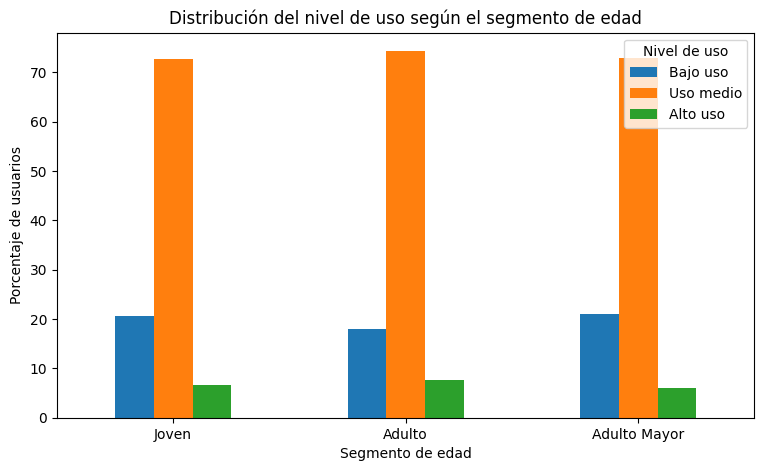

In [104]:
# Visualizar la distribución del nivel de uso según el segmento de edad
tabla_segmentos.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.xlabel("Segmento de edad")
plt.ylabel("Porcentaje de usuarios")
plt.title("Distribución del nivel de uso según el segmento de edad")
plt.xticks(rotation=0)
plt.legend(title="Nivel de uso")
plt.show()

### 6.4 Comparación de uso según el plan contratado

Se comparan las principales métricas de uso y la distribución de los niveles de actividad entre los planes Básico y Premium.

In [105]:
# Comparar el uso promedio según el tipo de plan
metricas_uso = [
    "cant_mensajes",
    "cant_llamadas",
    "cant_minutos_llamados"
]

user_profile.groupby("plan")[metricas_uso].mean().round(2)

,cant_mensajes,cant_llamadas,cant_minutos_llamados
plan,,,
Basico,5.53,4.46,22.58
Premium,5.52,4.52,23.31


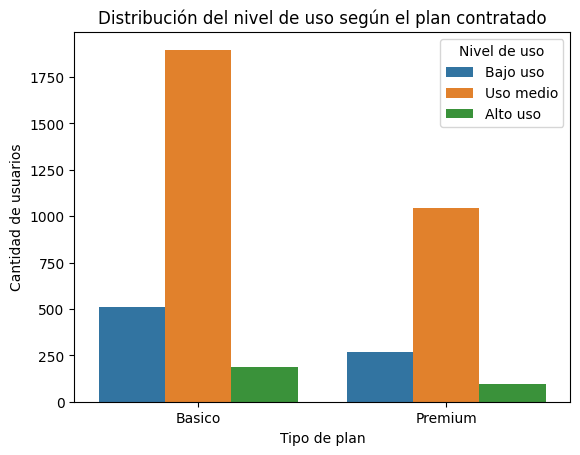

In [106]:
# Visualizar los segmentos de uso según el tipo de plan
sns.countplot(
    data=user_profile,
    x="plan",
    hue="grupo_uso",
    hue_order=["Bajo uso", "Uso medio", "Alto uso"]
)

plt.xlabel("Tipo de plan")
plt.ylabel("Cantidad de usuarios")
plt.title("Distribución del nivel de uso según el plan contratado")
plt.legend(title="Nivel de uso")
plt.show()

### 6.5 Exportación de visualizaciones para el README

Se generan versiones en inglés de las principales visualizaciones del análisis para su presentación en el README del proyecto.

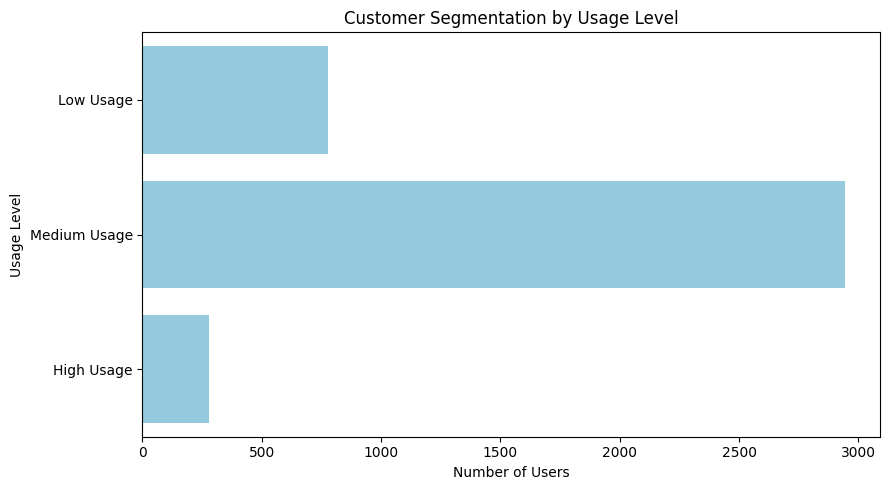

In [107]:
# Export README visualization: Usage Level Segmentation
usage_labels_en = {
    "Bajo uso": "Low Usage",
    "Uso medio": "Medium Usage",
    "Alto uso": "High Usage"
}

usage_order_en = [
    "Low Usage",
    "Medium Usage",
    "High Usage"
]

readme_usage = user_profile[
    user_profile["grupo_uso"] != "Sin datos de uso"
].copy()

readme_usage["usage_level"] = (
    readme_usage["grupo_uso"].map(usage_labels_en)
)

plt.figure(figsize=(9, 5))

sns.countplot(
    data=readme_usage,
    y="usage_level",
    order=usage_order_en,
    color="skyblue"
)

plt.xlabel("Number of Users")
plt.ylabel("Usage Level")
plt.title("Customer Segmentation by Usage Level")

plt.tight_layout()
plt.savefig(
    "images/usage_level_segmentation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

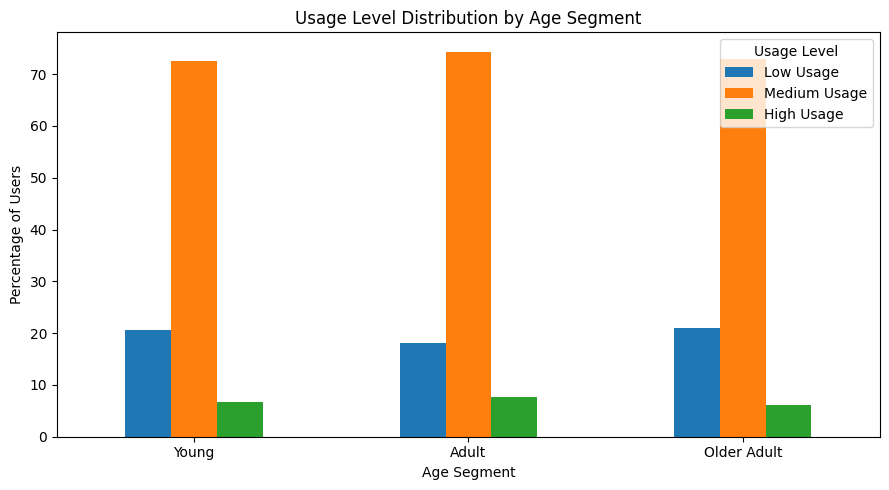

In [108]:
# Export README visualization: Usage Level by Age Segment
age_labels_en = {
    "Joven": "Young",
    "Adulto": "Adult",
    "Adulto Mayor": "Older Adult"
}

age_order_en = [
    "Young",
    "Adult",
    "Older Adult"
]

readme_segments = user_profile[
    user_profile["grupo_uso"] != "Sin datos de uso"
].copy()

readme_segments["age_segment"] = (
    readme_segments["grupo_edad"].map(age_labels_en)
)

readme_segments["usage_level"] = (
    readme_segments["grupo_uso"].map(usage_labels_en)
)

readme_age_usage = (
    pd.crosstab(
        readme_segments["age_segment"],
        readme_segments["usage_level"],
        normalize="index"
    )
    .mul(100)
    .reindex(index=age_order_en)
    .reindex(columns=usage_order_en)
)

readme_age_usage.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.xlabel("Age Segment")
plt.ylabel("Percentage of Users")
plt.title("Usage Level Distribution by Age Segment")
plt.xticks(rotation=0)
plt.legend(title="Usage Level")

plt.tight_layout()
plt.savefig(
    "images/usage_level_by_age.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

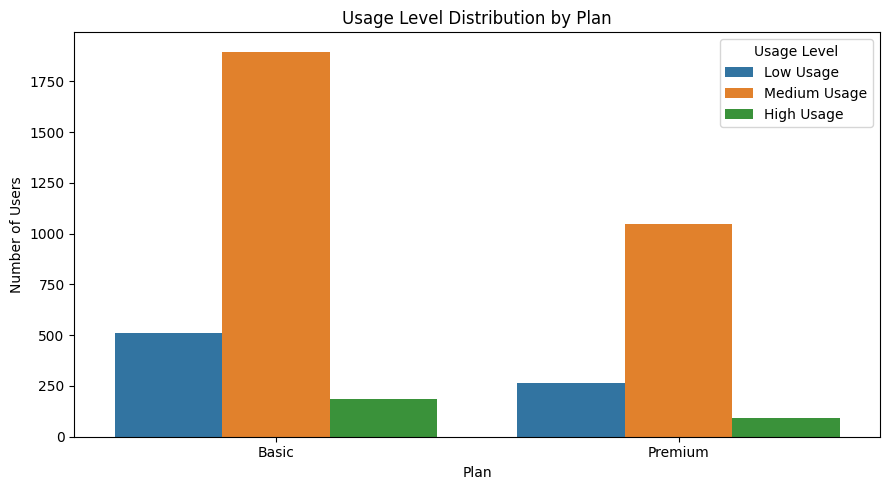

In [109]:
# Export README visualization: Usage Level by Plan
plan_labels_en = {
    "Basico": "Basic",
    "Premium": "Premium"
}

readme_plan = user_profile[
    user_profile["grupo_uso"] != "Sin datos de uso"
].copy()

readme_plan["plan_name"] = (
    readme_plan["plan"].map(plan_labels_en)
)

readme_plan["usage_level"] = (
    readme_plan["grupo_uso"].map(usage_labels_en)
)

plt.figure(figsize=(9, 5))

sns.countplot(
    data=readme_plan,
    x="plan_name",
    hue="usage_level",
    hue_order=usage_order_en
)

plt.xlabel("Plan")
plt.ylabel("Number of Users")
plt.title("Usage Level Distribution by Plan")
plt.legend(title="Usage Level")

plt.tight_layout()
plt.savefig(
    "images/usage_level_by_plan.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

---

## 7. Hallazgos y recomendaciones

Los principales resultados del análisis se consolidan a continuación, considerando los problemas de calidad identificados, los patrones de uso, la segmentación de clientes y las diferencias observadas según el plan contratado.

### 7.1 Problemas de calidad de los datos

- Se identificaron 55 edades con el valor sentinel -999 (1.38% de los usuarios). Estos valores se normalizaron como nulos y posteriormente se imputaron utilizando la mediana de edad.

- El atributo city presentó 469 valores nulos y 96 registros con "?". Estos últimos se estandarizaron como valores faltantes para mantener la consistencia de la variable.

- Se detectaron 40 fechas de registro correspondientes a 2026 (1% de los usuarios), fuera del periodo temporal esperado del dataset, por lo que se normalizaron como valores nulos.

- Los valores faltantes en duration y length responden principalmente a la estructura del tipo de evento. Además, se identificaron registros con información en campos no aplicables, los cuales se normalizaron como NaN según la estructura de llamadas y mensajes.

### 7.2 Segmentación y patrones de uso

🔍 **Segmentos por Edad**
- El segmento Adulto, compuesto por usuarios de entre 30 y 59 años, es el más numeroso, con 2,018 clientes, seguido de Adulto Mayor con 1,222 y Joven con 760.

- La distribución del nivel de uso es similar entre los tres grupos de edad. Aproximadamente entre el 73% y 74% de cada segmento presenta Uso medio, lo que sugiere que la edad, por sí sola, no explica diferencias relevantes en los patrones de uso observados.

📊 **Segmentos por Nivel de Uso**
- La mayoría de los clientes pertenece al segmento de Uso medio, con 2,943 usuarios. Bajo uso concentra 778 clientes y Alto uso 278. Adicionalmente, un usuario no presentó registros de actividad observados y fue clasificado como Sin datos de uso.

- El comportamiento predominante corresponde a un nivel de consumo moderado, mientras que los usuarios de Alto uso representan un grupo reducido con una actividad significativamente superior.

- Mediante el método IQR se identificaron valores atípicos en mensajes, llamadas y minutos totales de llamada. Estos registros mantienen valores coherentes con las métricas analizadas, por lo que se conservaron como posibles patrones reales de consumo intensivo.

### 7.3 Comportamiento según el plan contratado

* Los clientes de los planes Básico y Premium presentan niveles promedio de llamadas, mensajes y minutos muy similares. Asimismo, la distribución de los niveles de uso mantiene un patrón comparable entre ambos planes.

* Estos resultados indican que, considerando únicamente llamadas y mensajería, el tipo de plan contratado no parece estar asociado con diferencias relevantes en el comportamiento de uso.

* Sin embargo, el dataset no contiene información sobre consumo de datos móviles. Por este motivo, no es posible evaluar completamente las diferencias de comportamiento entre planes ni determinar si el consumo de datos explica la elección del plan Premium.

### 7.4 Recomendaciones

* Se recomienda priorizar estrategias comerciales sobre el segmento de Uso medio, ya que concentra la mayor parte de la base de clientes. Las acciones de fidelización o personalización dirigidas a este grupo podrían generar un mayor alcance.

* Los usuarios de Alto uso deberían analizarse como un segmento de consumo intensivo independiente, evaluando oportunidades de servicios o beneficios adaptados a su comportamiento antes de asumir que requieren una migración al plan Premium.

* Dado que los clientes Básico y Premium presentan patrones similares de llamadas y mensajería, se recomienda incorporar métricas de consumo de datos móviles en futuros análisis para comprender mejor las diferencias entre ambos grupos y evaluar la adecuación de la oferta actual de planes.

* Los usuarios con valores extremos de consumo pueden ser monitoreados para diferenciar patrones legítimos de uso intensivo de posibles anomalías operativas.

### 7.5 Limitaciones del análisis

El dataset de actividad disponible registra únicamente llamadas y mensajes. Aunque la información de planes incluye beneficios asociados al consumo de datos móviles, `usage.csv` no contiene métricas de uso de GB.

Por este motivo, las comparaciones entre los planes Básico y Premium se limitan al comportamiento de llamadas y mensajería. No es posible evaluar completamente la adecuación del plan contratado ni determinar si el consumo de datos móviles explica las diferencias en la elección del plan.

Adicionalmente, la segmentación por nivel de uso se basa en reglas predefinidas de llamadas y mensajes. Los grupos obtenidos deben interpretarse como segmentos operativos e interpretables dentro del alcance del análisis, y no como grupos derivados mediante técnicas estadísticas de clustering.